<a href="https://colab.research.google.com/github/FamerTech/Loan_Prediction_Model/blob/main/Loan_Default_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Loan Default Prediction System**

In [131]:
#Import necesassry libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score
sns.set_style('whitegrid')

In [115]:
# Loading the dataset into pandas dataframe
loan_dataset = pd.read_csv('/content/Loan_default.csv')
loan_dataset.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0.0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0.0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1.0
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0.0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0.0


In [116]:
# Identifying the total of rows and columns in the data
loan_dataset.shape

(150936, 18)

In [117]:
# Checking the nmissing value in the data
loan_dataset.isnull().sum()

,0
LoanID,0
Age,0
Income,0
LoanAmount,0
CreditScore,0
MonthsEmployed,0
NumCreditLines,0
InterestRate,0
LoanTerm,0
DTIRatio,0


In [118]:
# Marital status
loan_dataset.replace({'MaritalStatus': {'Divorced': 2, 'Single': 0, 'Married': 1}}, inplace=True)

loan_dataset.replace({'LoanPurpose': {'Home': 0, 'Business': 2, 'Education': 1, 'Auto': 3, 'Other': 4,}}, inplace=True)

loan_dataset.replace({'HasDependents': {'No': 0, 'Yes': 1}}, inplace=True)

loan_dataset.replace({'HasDependents' : {'No': 0, 'Yes': 1}}, inplace=True)

loan_dataset.replace({'HasMortgage' : {'No': 0, 'Yes': 1}}, inplace=True)

loan_dataset.replace({'HasCoSigner' : {'No': 0, 'Yes': 1}}, inplace=True)

loan_dataset.replace({'EmploymentType': {'Unemployed': 0, 'Self-employed': 1, 'Part-time': 2, 'Full-time': 3}}, inplace=True)

loan_dataset.replace({'Education': {'High School': 0, 'Bachelor\'s': 1, 'Master\'s': 2, 'PhD': 3}}, inplace=True)




/tmp/ipykernel_1742/4145034948.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  loan_dataset.replace({'LoanPurpose': {'Home': 0, 'Business': 2, 'Education': 1, 'Auto': 3, 'Other': 4,}}, inplace=True)
/tmp/ipykernel_1742/4145034948.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  loan_dataset.replace({'HasDependents': {'No': 0, 'Yes': 1}}, inplace=True)
/tmp/ipykernel_1742/4145034948.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, expli

In [119]:
loan_dataset.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,1,3,2,1.0,1.0,4.0,1.0,0.0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,2,3,1,0.0,0.0,4.0,1.0,0.0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,2,0,2,1.0,1.0,3.0,0.0,1.0
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,0,3,1,0.0,0.0,2.0,0.0,0.0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,1,0,2,0.0,1.0,3.0,0.0,0.0


In [120]:
loan_dataset['Education'].value_counts()

,count
Education,
1,38088
0,37718
3,37604
2,37526


In [121]:
loan_dataset['LoanPurpose'].value_counts()

,count
LoanPurpose,
2.0,30345
4.0,30195
0.0,30190
3.0,30124
1.0,30081


In [122]:
loan_dataset['LoanPurpose'].value_counts()

,count
LoanPurpose,
2.0,30345
4.0,30195
0.0,30190
3.0,30124
1.0,30081


In [123]:
loan_dataset.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,1,3,2,1.0,1.0,4.0,1.0,0.0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,2,3,1,0.0,0.0,4.0,1.0,0.0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,2,0,2,1.0,1.0,3.0,0.0,1.0
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,0,3,1,0.0,0.0,2.0,0.0,0.0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,1,0,2,0.0,1.0,3.0,0.0,0.0


In [124]:
# checking the statistical measures of the data
loan_dataset.describe()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
count,150936.000000,150936.000000,150936.000000,150936.000000,150936.000000,150936.000000,150936.000000,150936.000000,150936.000000,150936.000000,150936.000000,150935.000000,150935.000000,150935.000000,150935.000000,150935.000000
mean,43.521022,82533.622463,127546.912347,574.479355,59.559714,2.497675,13.497575,36.038162,0.500338,1.497005,1.500225,0.499738,0.499699,2.000351,0.501289,0.115301
std,14.979086,38948.711396,70877.905680,158.786607,34.644950,1.116844,6.639734,16.959948,0.230900,1.117168,1.116555,0.500002,0.500002,1.413925,0.500000,0.319386
min,18.000000,15000.000000,5001.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,31.000000,48836.750000,66122.500000,437.000000,30.000000,2.000000,7.780000,24.000000,0.300000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000
50%,44.000000,82572.000000,127342.000000,574.000000,60.000000,2.000000,13.470000,36.000000,0.500000,1.000000,2.000000,0.000000,0.000000,2.000000,1.000000,0.000000
75%,56.000000,116214.000000,189025.000000,712.000000,90.000000,3.000000,19.260000,48.000000,0.700000,2.000000,2.000000,1.000000,1.000000,3.000000,1.000000,0.000000
max,69.000000,149997.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,3.000000,3.000000,1.000000,1.000000,4.000000,1.000000,1.000000


Default rate: 11.5%


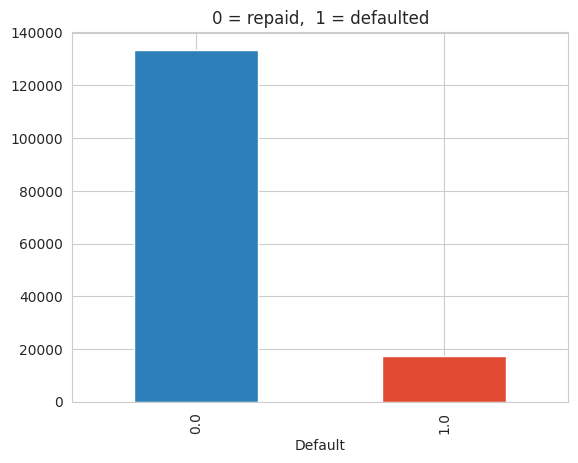

In [125]:

loan_dataset = pd.read_csv('/content/Loan_default.csv')
#Target balance — what % actually default?
rate = loan_dataset['Default'].mean()
print(f'Default rate: {rate:.1%}')
loan_dataset['Default'].value_counts().plot(kind='bar', color=['#2c7fb8','#e34a33'])
plt.title('0 = repaid,  1 = defaulted'); plt.show()
# NOTE: only ~12% default. The data is imbalanced — keep an eye on F1, not just accuracy.

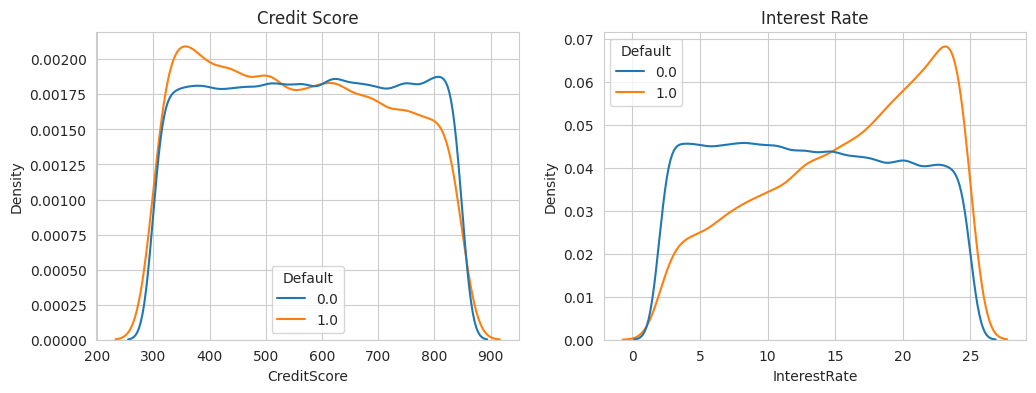

In [126]:
fig, ax = plt.subplots(1,2, figsize=(12,4))
sns.kdeplot(data=df, x='CreditScore', hue='Default', common_norm=False, ax=ax[0])
ax[0].set_title('Credit Score')
sns.kdeplot(data=df, x='InterestRate', hue='Default', common_norm=False, ax=ax[1])
ax[1].set_title('Interest Rate')
plt.show()

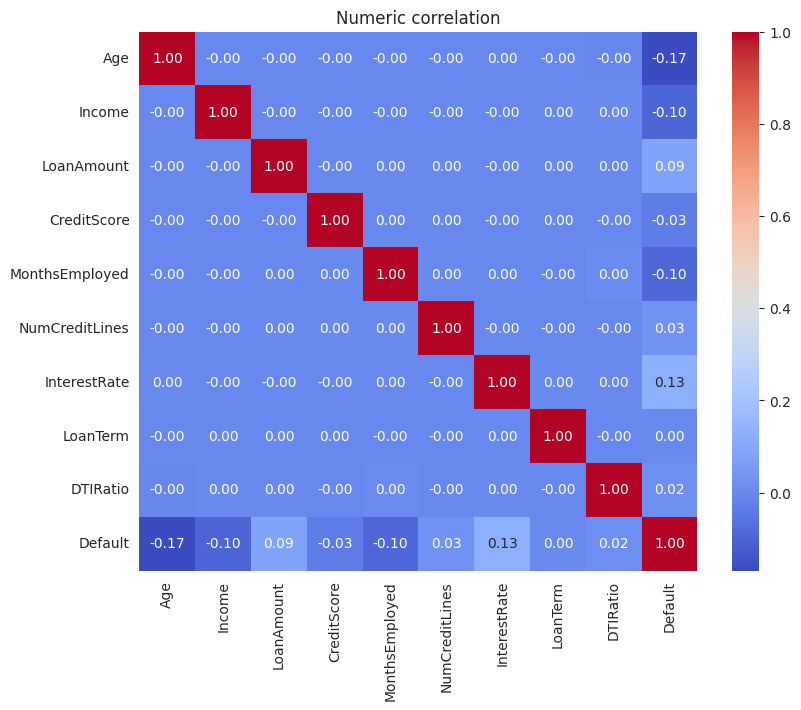

In [127]:
# correction
num = ['Age','Income','LoanAmount','CreditScore','MonthsEmployed',
       'NumCreditLines','InterestRate','LoanTerm','DTIRatio']
plt.figure(figsize=(9,7))
sns.heatmap(df[num+['Default']].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Numeric correlation'); plt.show()

In [128]:
loan_dataset.tail()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
150931,TXL0KG081U,23,26269,137920,412,17,3,16.53,36,0.51,PhD,Part-time,Single,No,No,Home,No,1.0
150932,IJYX89V0DC,50,77729,236231,739,23,3,15.74,60,0.22,PhD,Self-employed,Divorced,No,No,Home,Yes,0.0
150933,G1R5PL187X,62,113029,237924,784,66,3,17.70,36,0.13,Bachelor's,Unemployed,Married,No,No,Other,Yes,0.0
150934,XUNCC7MNSW,49,68946,176461,407,71,3,23.23,36,0.26,Master's,Full-time,Single,No,No,Education,Yes,0.0
150935,UEJHFTO89H,29,125011,205692,523,106,2,16.66,12,0.75,Master's,Unemployed,S,NaN,NaN,NaN,NaN,NaN


Dropping Default column,LoanID, and Creditscore

In [129]:


X = loan_dataset.drop(columns=['Default', 'LoanID'], axis=1)

# Separate target variable 'Default'
y = loan_dataset['Default']



print(f"Processed X shape: {X.shape}")
print(f"y shape: {y.shape}")

Processed X shape: (150936, 16)
y shape: (150936,)


Train Split Test

In [150]:
from sklearn.model_selection import train_test_split
loan_dataset = pd.read_csv('/content/Loan_default.csv')
X_train, X_test, y_train,y_test = train_test_split = train_test_split(X,y, test_size = 0.2, random_state = 2)

In [151]:
# Display the first 5 rows of x
print(X.shape, X_train.shape, X_test.shape)

(150936, 16) (120748, 16) (30188, 16)


Model training:
 XGBClassifier

In [134]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score # Import accuracy_score

# Identify categorical columns that are still of object type in X_train
categorical_cols = X_train.select_dtypes(include='object').columns

# Convert these columns to 'category' dtype in both X_train and X_test
for col in categorical_cols:
    X_train[col] = X_train[col].astype('category')
    X_test[col] = X_test[col].astype('category')

model = XGBClassifier(random_state=2, enable_categorical=True) # Initialize the model with a random state and enable categorical feature handling
model.fit(X_train, y_train) # Train the model



XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

### Feature Importances

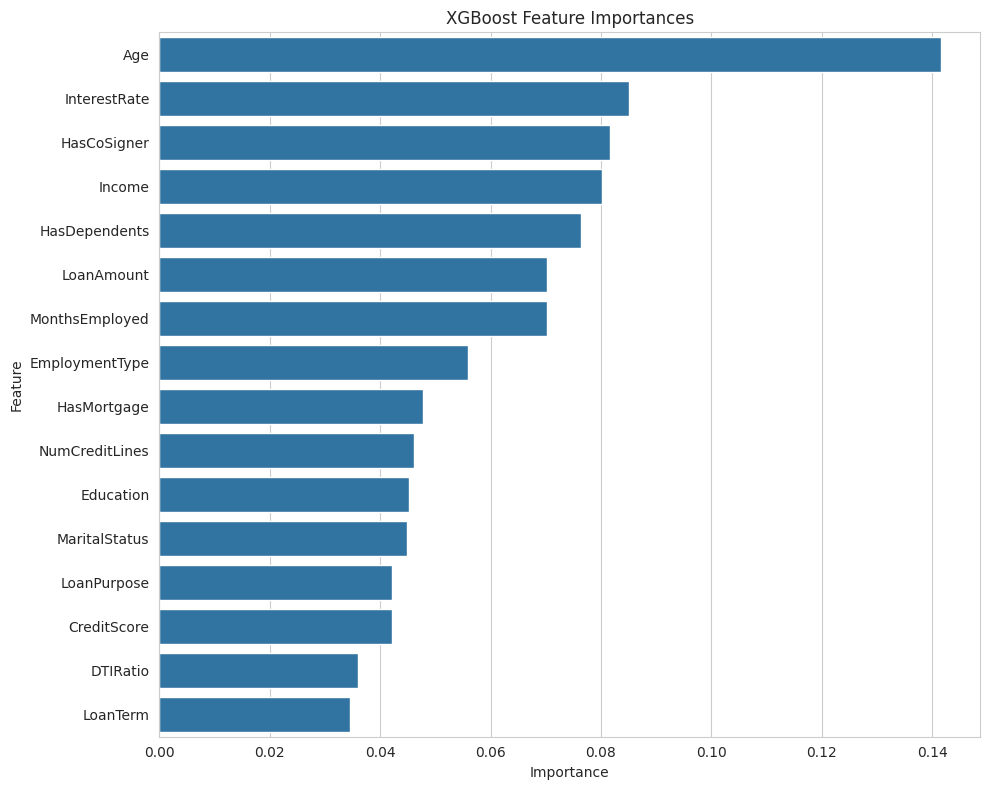

In [135]:
feature_importances = model.feature_importances_
feature_names = X_train.columns

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# Sort by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot feature importances
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('XGBoost Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

Model Evaluation:
Accuracy_scrore

In [146]:
# accuracy_score for the model evaluation
X_train_prediction = model.predict(X_train)
training_data_accuracy = accuracy_score(X_train_prediction, y_train)
print(f"Accuracy Score for X_train : {training_data_accuracy}")

Accuracy Score for X_train : 0.9006194719581276


In [147]:
# accuracy_score for the model evaluation
X_test_prediction = model.predict(X_test)
test_data_accuracy = accuracy_score(X_test_prediction, y_test)
print(f"Accuracy Score for X_test : {test_data_accuracy}")

Accuracy Score for X_test : 0.8850167290555537


Prediction System

In [152]:
input_data = (31.0,24404.0,182711.0,485.0,50.0,2.0,24.86,60.0,0.72,2.0,1.0,0.0,1.0,0.0,0.0,0.0)

# change the input to the numpy array
input_data_as_numpy_array = np.asarray(input_data)
input_data_reshaped = input_data_as_numpy_array.reshape(1, -1)
prediction = model.predict(input_data_reshaped)

if prediction[0] == 0:
  print("This person are not qualify for the loan")
else:
    print("This person quilified for the loan")


This person are not qualify for the loan


Saving the trained model

In [140]:

import pickle

In [141]:
filename = 'loan_predictive_model.sav'
pickle.dump(model, open(filename, 'wb'))

In [142]:
# loading the saved model
loaded_model = pickle.load(open('loan_predictive_model.sav', 'rb'))

In [143]:
for column in X.columns:
  print(column)


Age
Income
LoanAmount
CreditScore
MonthsEmployed
NumCreditLines
InterestRate
LoanTerm
DTIRatio
Education
EmploymentType
MaritalStatus
HasMortgage
HasDependents
LoanPurpose
HasCoSigner


Streamlit Installation

In [153]:
!pip install streamlit

In [154]:
import os, pickle

# Create the directory if it doesn't exist
os.makedirs("saved_model", exist_ok=True)

# Save the model to the specified path
with open('saved_model/loan_predictive_model.sav', 'wb') as f:
     pickle.dump(model, f)
     print('Model successfully saved')


Model successfully saved
